# 06 · Peer clustering

**Question.** Do data-driven groups of companies match the sector labels FinSight uses as peer groups?

Results are read from the stored run (`python scripts/run_ml.py`); nothing is refitted here. Descriptive: it describes the last five years.

*FinSight is an analytics tool, not investment advice.*

## 1. Data

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

from src.database import queries
from src.database.connection import get_engine
from src.formatting import format_crore, format_metric, format_pct

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})
ACCENT, GREY = "#1f4e79", "#8c8c8c"

with get_engine().connect() as conn:
    companies = queries.load_companies(conn)
    metrics = queries.load_metrics(conn)
    statements = queries.load_statements(conn)
    prices = queries.load_prices(conn)
    as_of = queries.load_latest_price_date(conn).iloc[0]["latest"]
firms = companies[companies["entity_type"] == "company"].reset_index(drop=True)
short = lambda t: t.replace(".NS", "")
print(f"{len(firms)} companies in {firms['sector_name'].nunique()} sectors | "
      f"{len(metrics):,} stored metric rows | prices to {as_of}")

with get_engine().connect() as conn:
    run = pd.read_sql(text("SELECT * FROM core.ml_runs WHERE task = 'clustering'"), conn).iloc[0]
    clusters = queries.load_ml_clusters(conn)
results, params = run["results"], run["params"]
features = pd.DataFrame(results["features"]).set_index("ticker")
print(f"Seed {run['seed']}, snapshot {run['data_snapshot_id']}: {params['n_companies']} "
      f"companies, {params['n_days']:,} trading days, {params['n_sectors']} sectors.")
print("Features:", params["features"], "| imputed:", params["imputed"] or "none")
features.round(3).head(8)

25 companies in 5 sectors | 6,146 stored metric rows | prices to 2026-10-06
Seed 42, snapshot 2dca6b196267: 25 companies, 1,221 trading days, 5 sectors.
Features: ['volatility', 'beta', 'market_correlation', 'net_margin', 'roe', 'revenue_growth'] | imputed: none


,roe,beta,net_margin,volatility,revenue_growth,market_correlation
ticker,,,,,,
ASIANPAINT.NS,0.212,0.722,0.122,0.222,0.051,0.450
AXISBANK.NS,0.131,1.084,0.300,0.244,0.040,0.615
BAJAJ-AUTO.NS,0.290,0.786,0.178,0.245,0.226,0.444
BRITANNIA.NS,0.535,0.504,0.134,0.204,0.075,0.343
CIPLA.NS,0.118,0.427,0.140,0.229,0.021,0.258
DIVISLAB.NS,0.162,0.632,0.245,0.268,0.123,0.327
DRREDDY.NS,0.121,0.523,0.128,0.217,0.032,0.334
EICHERMOT.NS,0.238,1.028,0.240,0.262,0.239,0.543


## 2. Method

- **K-means** on six standardized features: volatility, beta, correlation with the market, net margin, ROE, revenue growth. *Similar risk and business profile.*
- **Hierarchical clustering** (average linkage) on the distance 1 − correlation of daily returns. *Prices that move together.*
- k chosen by the highest silhouette score over k = 2..8; the elbow curve is shown.
- Agreement with sectors by adjusted Rand index (1 = identical, about 0 = chance); stability by re-clustering 200 block-bootstrap resamples and the two halves of the sample.
- Only fundamentals that apply to every sector type are used, so banks are clustered on the same features as everyone else.

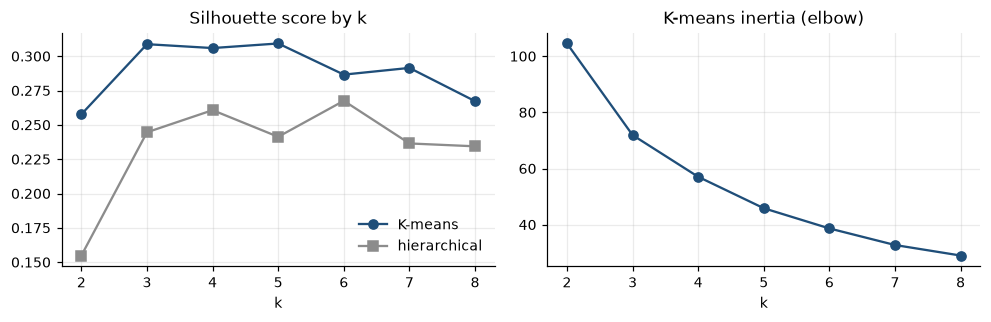

Chosen k: K-means 5 (silhouette 0.309), hierarchical 6 (silhouette 0.268).
K-means silhouette for k = 3, 4, 5: 0.309, 0.306, 0.309: nearly flat, so its k is not sharply determined.


In [2]:
selection = pd.DataFrame(results["selection"])
pivot = selection.pivot(index="k", columns="method", values="silhouette")
inertia = selection[selection["method"] == "kmeans"].set_index("k")["inertia"]
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(pivot.index, pivot["kmeans"], marker="o", color=ACCENT, label="K-means")
axes[0].plot(pivot.index, pivot["hierarchical"], marker="s", color=GREY, label="hierarchical")
axes[0].set_title("Silhouette score by k"); axes[0].set_xlabel("k"); axes[0].legend(frameon=False)
axes[1].plot(inertia.index, inertia, marker="o", color=ACCENT)
axes[1].set_title("K-means inertia (elbow)"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()
s = results["summary"]
print(f"Chosen k: K-means {s['kmeans']['k']} (silhouette {s['kmeans']['silhouette']:.3f}), "
      f"hierarchical {s['hierarchical']['k']} (silhouette {s['hierarchical']['silhouette']:.3f}).")
k = pivot["kmeans"]
print(f"K-means silhouette for k = 3, 4, 5: {k[3]:.3f}, {k[4]:.3f}, {k[5]:.3f}: nearly flat, so "
      "its k is not sharply determined.")

## 3. Results

### 3.1 Agreement with sector labels

In [3]:
table = pd.DataFrame({
    "K-means (features)": [s["kmeans"]["k"], s["kmeans"]["ari_vs_sector"],
                           s["kmeans"]["ari_vs_sector_at_sector_count"]],
    "Hierarchical (returns)": [s["hierarchical"]["k"], s["hierarchical"]["ari_vs_sector"],
                               s["hierarchical"]["ari_vs_sector_at_sector_count"]]},
    index=["k chosen", "ARI vs sector at chosen k", f"ARI vs sector at k = {params['n_sectors']}"])
print(table.round(3).to_string())
print(f"\nARI between the two methods' groupings: {s['kmeans_vs_hierarchical_ari']:.3f}")
for method in ("hierarchical", "kmeans"):
    print(f"\n{method} clusters by sector:")
    print(pd.DataFrame(results["crosstab"][method]).set_index("sector").to_string())
    for line in results["mismatches"][method]:
        print("  -", line)

                           K-means (features)  Hierarchical (returns)
k chosen                                5.000                   6.000
ARI vs sector at chosen k               0.407                   0.950
ARI vs sector at k = 5                  0.407                   0.702

ARI between the two methods' groupings: 0.390

hierarchical clusters by sector:
                        0  1  2  3  4  5
sector                                  
Auto                    0  0  0  5  0  0
Consumer                0  0  0  0  4  1
Financials              0  0  5  0  0  0
Information Technology  0  5  0  0  0  0
Pharmaceuticals         5  0  0  0  0  0
  - Cluster 0 contains only Pharmaceuticals companies (CIPLA, DIVISLAB, DRREDDY, LUPIN, SUNPHARMA).
  - Cluster 1 contains only Information Technology companies (HCLTECH, INFY, TCS, TECHM, WIPRO).
  - Cluster 2 contains only Financials companies (AXISBANK, HDFCBANK, ICICIBANK, KOTAKBANK, SBIN).
  - Cluster 3 contains only Auto companies (BAJAJ-AUTO, 

### 3.2 The two views

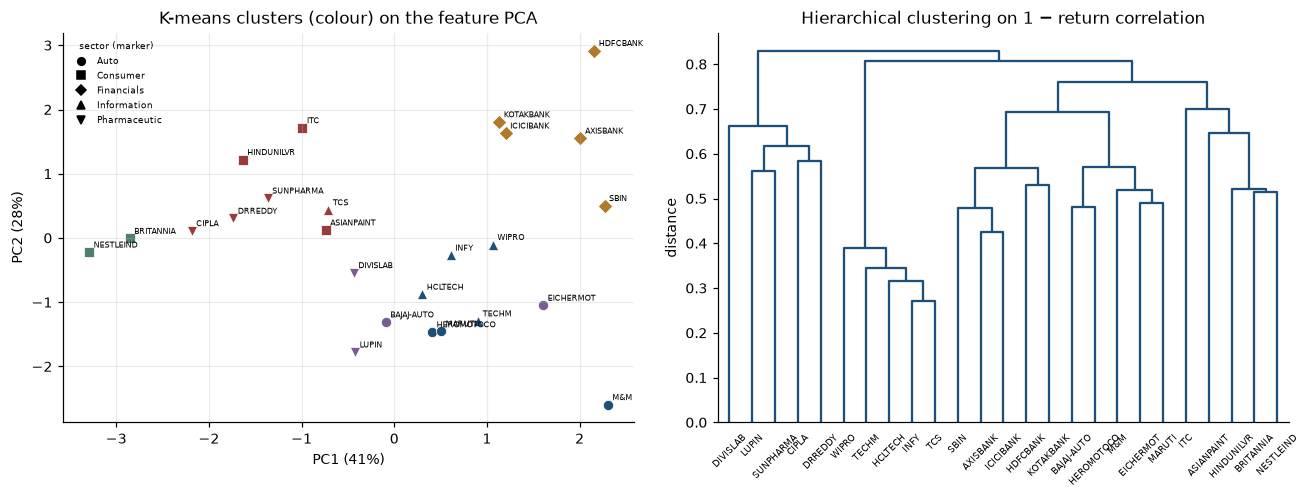

In [4]:
from scipy.cluster.hierarchy import dendrogram

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
markers = dict(zip(sorted(clusters["sector"].unique()), ["o", "s", "D", "^", "v"]))
palette = [ACCENT, "#b07a2a", "#4f7f6f", "#7a5c8e", "#9a3b3b", GREY, "#3f6f9f", "#a0a060"]
for row in clusters.itertuples():
    axes[0].scatter(row.pc1, row.pc2, marker=markers[row.sector], s=45,
                    color=palette[row.kmeans_cluster % len(palette)], edgecolor="white", lw=0.5)
    axes[0].annotate(short(row.ticker), (row.pc1, row.pc2), fontsize=5.5, xytext=(3, 3),
                     textcoords="offset points")
handles = [plt.Line2D([], [], marker=m, ls="", color="black", ms=5, label=sec[:12])
           for sec, m in markers.items()]
axes[0].legend(handles=handles, frameon=False, fontsize=6, title="sector (marker)", title_fontsize=6)
explained = params["pca_explained_variance"]
axes[0].set_xlabel(f"PC1 ({explained[0]:.0%})"); axes[0].set_ylabel(f"PC2 ({explained[1]:.0%})")
axes[0].set_title("K-means clusters (colour) on the feature PCA")
dendrogram(np.array(results["linkage"]), labels=[short(t) for t in results["linkage_labels"]],
           ax=axes[1], leaf_font_size=6, color_threshold=0, above_threshold_color=ACCENT)
axes[1].set_title("Hierarchical clustering on 1 − return correlation")
axes[1].set_ylabel("distance"); axes[1].grid(False)
plt.tight_layout(); plt.show()

### 3.3 Stability

In [5]:
stability = pd.DataFrame(results["stability"]).rename(
    columns={"kmeans": "K-means", "hierarchical": "Hierarchical"})
print(stability.round(3).to_string())
h, km = results["stability"]["hierarchical"], results["stability"]["kmeans"]
print(f"\nBootstrap ARI against the full-sample clusters: hierarchical mean "
      f"{h['bootstrap_mean_ari']:.2f} (5th percentile {h['bootstrap_p05_ari']:.2f}); K-means mean "
      f"{km['bootstrap_mean_ari']:.2f} (5th percentile {km['bootstrap_p05_ari']:.2f}).")

                          K-means  Hierarchical
resamples                 200.000       200.000
bootstrap_p05_ari           0.479         0.686
bootstrap_p95_ari           1.000         1.000
bootstrap_mean_ari          0.715         0.929
first_half_vs_full_ari      0.539         1.000
second_half_vs_full_ari     0.581         1.000
first_vs_second_half_ari    0.653         1.000

Bootstrap ARI against the full-sample clusters: hierarchical mean 0.93 (5th percentile 0.69); K-means mean 0.72 (5th percentile 0.48).


## 4. Interpretation

- **Grouping by how prices move reproduces the sectors.** Hierarchical clustering on return correlations agrees with the sector labels almost exactly at its chosen k, and the cross-tab shows the single departure. It is stable across resamples and identical in both halves of the sample.
- **Grouping by company characteristics does not.** K-means on risk and fundamental features separates the banks cleanly but mixes the other sectors: an IT company can resemble an auto company on volatility, margins and growth while trading with its own sector. Its clusters are also less stable, and its k is not sharply determined.
- For comparable-company analysis this supports using sector-based peer groups: they are the grouping the market itself prices together. It also says that 'peer' means 'co-moving', not 'similar-looking', which is a caveat on comparing fundamentals within a peer group.

## 5. Limitations

- 25 companies, five per sector: one company changing cluster moves the ARI noticeably.
- The universe was built as five well-known companies from each sector. The close match between return clusters and sectors is partly a property of that tidy design and would be weaker in a broad universe.
- Fundamentals come from one fiscal year and are held fixed in the stability check.
- K-means depends on the feature set and scaling; another reasonable set would give other clusters.
- Silhouette scores of 0.27–0.31 indicate weak-to-moderate structure.

*FinSight is an analytics tool, not investment advice.*